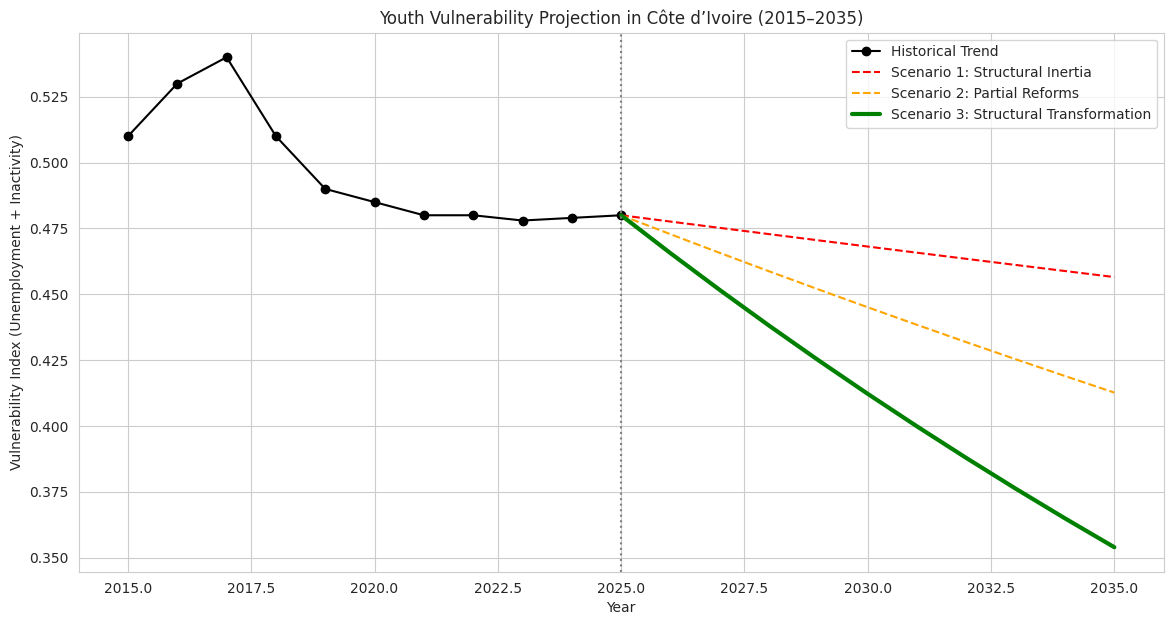

                    Scenario  2035 Projection  Total Reduction (%)
0         Structural Inertia         0.456533             0.048890
1            Partial Reforms         0.412671             0.140270
2  Structural Transformation         0.353964             0.262576


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BASE DATA

years_hist = np.arange(2015, 2026)

vulnerability_hist = np.array([
    0.51, 0.53, 0.54, 0.51, 0.49,
    0.485, 0.48, 0.48, 0.478, 0.479, 0.48
])

years_proj = np.arange(2025, 2036)
v0 = vulnerability_hist[-1]

# DECAY MODEL

def scenario(v0, years, rate):
    return [v0 * ((1 - rate) ** i) for i in range(len(years))]

# SCENARIOS

# Scenario 1: Structural inertia
scenario_1 = scenario(v0, years_proj, rate=0.005)

# Scenario 2: Partial reforms
scenario_2 = scenario(v0, years_proj, rate=0.015)

# Scenario 3: Structural transformation
scenario_3 = scenario(v0, years_proj, rate=0.03)

# VISUALIZATION

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

plt.plot(
    years_hist,
    vulnerability_hist,
    label="Historical Trend",
    color="black",
    marker="o"
)

plt.plot(
    years_proj,
    scenario_1,
    "--",
    label="Scenario 1: Structural Inertia",
    color="red"
)

plt.plot(
    years_proj,
    scenario_2,
    "--",
    label="Scenario 2: Partial Reforms",
    color="orange"
)

plt.plot(
    years_proj,
    scenario_3,
    label="Scenario 3: Structural Transformation",
    color="green",
    linewidth=3
)

plt.axvline(2025, color="gray", linestyle=":")

plt.title("Youth Vulnerability Projection in Côte d’Ivoire (2015–2035)")
plt.xlabel("Year")
plt.ylabel("Vulnerability Index (Unemployment + Inactivity)")
plt.legend()

plt.show()

# FINAL SUMMARY TABLE

df = pd.DataFrame({
    "Scenario": [
        "Structural Inertia",
        "Partial Reforms",
        "Structural Transformation"
    ],
    "2035 Projection": [
        scenario_1[-1],
        scenario_2[-1],
        scenario_3[-1]
    ],
    "Total Reduction (%)": [
        (v0 - scenario_1[-1]) / v0,
        (v0 - scenario_2[-1]) / v0,
        (v0 - scenario_3[-1]) / v0
    ]
})

print(df)